#  Phase noise measurement plots
FSWP settings (make sure to disable smoothing and spur removal):
* correlation factor = 2
* RBW = 10%
* Span = [1Hz, 1 MHz]

In [1]:
import pandas as pd
from scipy.integrate import cumulative_trapezoid
import numpy as np
from IPython.display import SVG, Image
import matplotlib.pyplot as plt

In [2]:
data_info = {
    'inst_absolute': {
        'desc': 'Instrument Absolute Phase Noise',
        'data': 'data/sma100b.dat',
        'screenshot': 'data/sma100b.png',
        'diagram': 'diagrams/inst_absolute.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': 9.32,
    },
    'inst_additive': {
        'desc': 'Instrument Additive Phase Noise',
        'data': 'data/instrument.dat',
        'screenshot': 'data/instrument.png',
        'diagram': 'diagrams/inst_additive.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': 9.26,
    },
    'lmk04828_absolute': {
        'desc': 'LMK4828B Absolute Phase Noise',
        'data': 'data/lmk04828_sma100b.dat',
        'screenshot': 'data/lmk04828_sma100b.png',
        'diagram': 'diagrams/lmk04828_absolute.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': 2.28,
    },
    'lmk04828_additive': {
        'desc': 'LMK4828B Additive Phase Noise',
        'data': 'data/lmk04828_fswp.dat',
        'screenshot': 'data/lmk04828_fswp.png',
        'diagram': 'diagrams/lmk04828_additive.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': 0.78,
    },
    'clk104_absolute': {
        'desc': 'CLK104 Absolute Phase Noise',
        'data': 'data/clk104_sma100b.dat',
        'screenshot': 'data/clk104_sma100b.png',
        'diagram': 'diagrams/clk104_absolute.drawio.svg',
        'f_c': 499.64e6 * 8,
        'power_dBm': 0.70,
    },
    'clk104_additive': {
        'desc': 'CLK104 Additive Phase Noise',
        'data': 'data/clk104_fswp.dat',
        'screenshot': 'data/clk104_fswp.png',
        'diagram': 'diagrams/clk104_additive.drawio.svg',
        'f_c': 499.64e6 * 8,
        'power_dBm': 0.78,
    },
    'dac_absolute': {
        'desc': 'RFSoC DAC Absolute Phase Noise',
        'data': 'data/dac_sma100b.dat',
        'screenshot': 'data/dac_sma100b.png',
        'diagram': 'diagrams/dac_absolute.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': -8.30,
    },
    'dac_additive': {
        'desc': 'RFSoC DAC Additive Phase Noise',
        'data': 'data/dac_fswp.dat',
        'screenshot': 'data/dac_fswp.png',
        'diagram': 'diagrams/dac_additive.drawio.svg',
        'f_c': 499.64e6,
        'power_dBm': -8.32,
    }
}

Load all data

In [3]:
def calc_cum_jitter(psd, f_off, f_c):
    """
    Calculate cumulative RMS time jitter from phase noise power.
    Arguments:
    psd: array of phase noise power [rad^2]
    f_off: array of offset frequency [Hz]
    f_c: carrier frequency [Hz]
    Returns: RMS time jitter [s]
    """
    ph_noise = cumulative_trapezoid(10**(psd/10), f_off)
    ph_noise = np.insert(ph_noise, 0, 0)
    return np.sqrt(ph_noise) / 2 / np.pi / f_c

dfs = []
for k, v in data_info.items():
    df = pd.read_csv(
        v['data'], sep=';', usecols=[0,1],
        skiprows=2, names=['Offset Freq [Hz]', k], index_col=0)
    df[k + '_jitter'] = calc_cum_jitter(df[k], df.index, v['f_c'])
    dfs.append(df)
df = pd.concat(dfs, axis=1)

# Instrument phase noise

* SMA100b Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/inst_absolute.drawio.svg)


* FSWP Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/inst_additive.drawio.svg)


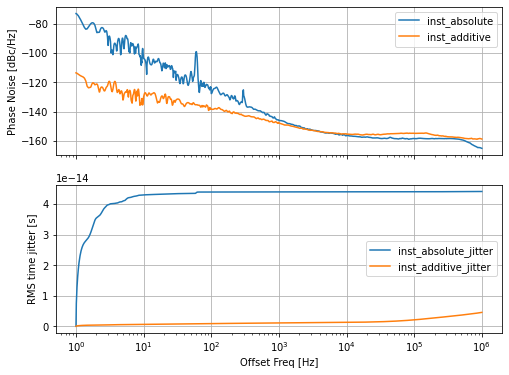

In [4]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['inst_absolute', 'inst_additive']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['inst_absolute_jitter', 'inst_additive_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [5]:
for k in ['inst_absolute_jitter', 'inst_additive_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

inst_absolute_jitter RMS time jitter:    44.1 fs
inst_additive_jitter RMS time jitter:     4.5 fs


# LMK04828 phase noise

* Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/lmk04828_absolute.drawio.svg)


* Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/lmk04828_additive.drawio.svg)


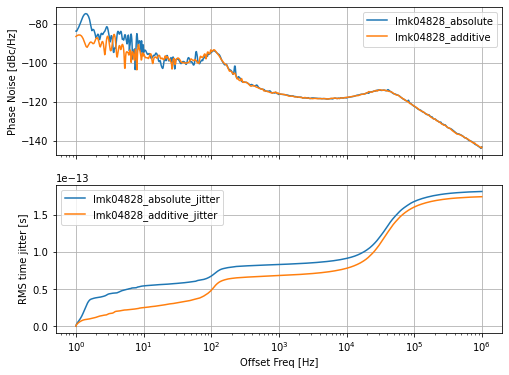

In [6]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['lmk04828_absolute', 'lmk04828_additive']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['lmk04828_absolute_jitter', 'lmk04828_additive_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [7]:
for k in ['lmk04828_absolute_jitter', 'lmk04828_additive_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

lmk04828_absolute_jitter RMS time jitter:   181.7 fs
lmk04828_additive_jitter RMS time jitter:   174.6 fs


# CLK104 phase noise

* Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/clk104_absolute.drawio.svg)


* Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/clk104_additive.drawio.svg)


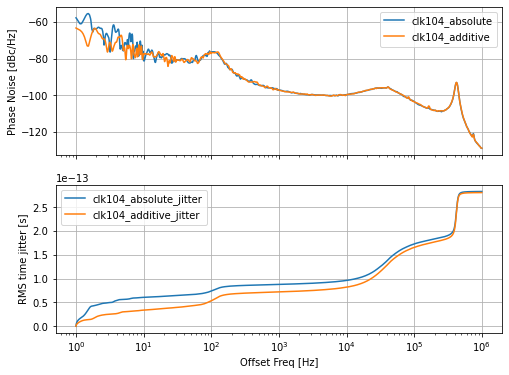

In [8]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['clk104_absolute', 'clk104_additive']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['clk104_absolute_jitter', 'clk104_additive_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [9]:
for k in ['clk104_absolute_jitter', 'clk104_additive_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

clk104_absolute_jitter RMS time jitter:   283.3 fs
clk104_additive_jitter RMS time jitter:   280.9 fs


# DAC phase noise

* Absolute Phase Noise

    Setup:

    ![inst_absolute](diagrams/dac_absolute.drawio.svg)


* Additive Phase Noise

    Setup:

    ![inst_additive](diagrams/dac_additive.drawio.svg)


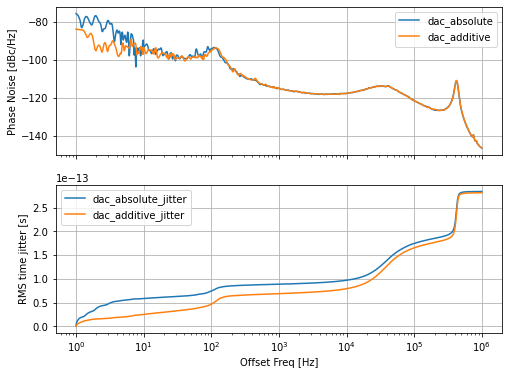

In [10]:
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
df[['dac_absolute', 'dac_additive']].plot(
    ax = axes[0],
    logx=True, grid=True, ylabel='Phase Noise [dBc/Hz]');
df[['dac_absolute_jitter', 'dac_additive_jitter']].plot(
    ax = axes[1],
    logx=True, grid=True, ylabel='RMS time jitter [s]');

In [11]:
for k in ['dac_absolute_jitter', 'dac_additive_jitter']:
    print(f'{k} RMS time jitter:{df[k].values[-1] * 1e15:8.1f} fs')

dac_absolute_jitter RMS time jitter:   283.8 fs
dac_additive_jitter RMS time jitter:   281.2 fs
